# Gate/Latch RMSD-to-Boltz-Reference — sequencing-confirmed candidates

Compares gate and latch C-alpha RMSD-to-own-Boltz-reference between binder and
nonbinder sequences, restricted to sequencing-confirmed candidates
(`source == "ngs_observed"` in `md_candidate_guide.csv`). Reads outputs already
produced by `extract_gate_latch_rmsd_feats.py`.

Produces:
1. Early vs. late window RMSD-to-ref by group, bar chart + per-sequence points.
2. Mean +/- IQR band of RMSD-to-ref over time, one panel per region.


In [1]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from extract_gate_latch_rmsd_feats import BASE, TAG, seq_run_dir

REPO_DIR    = "/Users/ivanatang/Developer/biosensors"
GUIDE_CSV   = os.path.join(REPO_DIR, "md_candidate_guide.csv")
SUMMARY_CSV = os.path.join(REPO_DIR, "analysis", f"gate_latch_rmsd_to_ref_summary{TAG}.csv")
OUT_DIR     = os.path.join(REPO_DIR, "analysis", "gate_latch")

GROUP_COLOR = {
    "Binder":         "#648FFF",
    "False Positive": "#DC267F",
    "Low Confidence": "#FE6100",
    "Fail Geometry":  "#FFB000",
}

SUFFIXES = ["_binder", "_low_pkt", "_fail_gate", "_nb"]


def strip_suffix(seq_id):
    for suf in SUFFIXES:
        if seq_id.endswith(suf):
            return seq_id[: -len(suf)]
    return seq_id


def load_ngs_observed_ids(guide_csv):
    with open(guide_csv) as f:
        rows = list(csv.DictReader(f))
    return {row["pair_id"] for row in rows if row["source"] == "ngs_observed"}


def get_data(filepath):
    """Parse a GROMACS-style .xvg file, skipping comment/annotation lines."""
    x_data, y_data = [], []
    with open(filepath) as f:
        for line in f:
            if line.startswith(('#', '@')):
                continue
            cols = line.split()
            if len(cols) >= 2:
                x_data.append(float(cols[0]))
                y_data.append(float(cols[1]))
    return np.array(x_data), np.array(y_data)


def load_region_ts(seq_id, group_label, fname):
    run_dir = seq_run_dir(seq_id, group_label)
    path = os.path.join(run_dir, fname)
    if not os.path.exists(path):
        return None
    return get_data(path)


os.makedirs(OUT_DIR, exist_ok=True)

## Standalone run: extraction restricted to sequencing-confirmed (`ngs_observed`) candidates only

Runs `extract_gate_latch_rmsd_feats.py` against a seq list filtered to
`source == "ngs_observed"` in `md_candidate_guide.csv`, tagged separately
(`_ngs_observed`) so it doesn't overwrite the full-cohort summary. Produces
its own `gate_latch_rmsd_to_ref_summary{TAG}_ngs_observed.csv` for inspecting
this subset independent of the full run below.

In [2]:
import subprocess
import sys

ngs_ids = load_ngs_observed_ids(GUIDE_CSV)

# Filter seq_ids_orig.txt down to sequencing-confirmed candidates only,
# keeping the same tab-separated seq_id/Group format.
filtered_seq_list = os.path.join(REPO_DIR, "seq_ids_ngs_observed.txt")
with open(os.path.join(REPO_DIR, "seq_ids_orig.txt")) as f_in, open(filtered_seq_list, "w") as f_out:
    n_written = 0
    for line in f_in:
        stripped = line.rstrip("\n")
        if not stripped or stripped.startswith("#"):
            continue
        seq_id = stripped.split("\t")[0].strip()
        if strip_suffix(seq_id) in ngs_ids:
            f_out.write(stripped + "\n")
            n_written += 1

print(f"Wrote {n_written} sequencing-confirmed sequences -> {filtered_seq_list}")

result = subprocess.run(
    [sys.executable, "extract_gate_latch_rmsd_feats.py", filtered_seq_list,
     "--tag", f"{TAG}_ngs_observed"],
    cwd=REPO_DIR, capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("extract_gate_latch_rmsd_feats.py failed")

Wrote 95 sequencing-confirmed sequences -> /Users/ivanatang/Developer/biosensors/seq_ids_ngs_observed.txt


Saved (95 rows) -> /Users/ivanatang/Developer/biosensors/analysis/gate_latch_rmsd_to_ref_summary_500ns_ngs_observed.csv



## Load summary CSV and filter to `ngs_observed` sequences

In [3]:
ngs_ids = load_ngs_observed_ids(GUIDE_CSV)

df = pd.read_csv(SUMMARY_CSV)
df["pair_id_guess"] = df["Sequence"].apply(strip_suffix)
confirmed = df[
    df["pair_id_guess"].isin(ngs_ids) & df["Group"].isin(["Binder", "False Positive"])
].copy()

binder = confirmed[confirmed["Group"] == "Binder"]
nb     = confirmed[confirmed["Group"] == "False Positive"]

print(f"Confirmed (ngs_observed) sequences: {len(confirmed)} "
      f"(binder={len(binder)}, nonbinder={len(nb)})")
confirmed.head()

Confirmed (ngs_observed) sequences: 95 (binder=47, nonbinder=48)


,Sequence,Group,Gate RMSD mean (A),Gate RMSD SD (A),Latch RMSD mean (A),Latch RMSD SD (A),N frames,Gate RMSD early100 mean (A),Gate RMSD late100 mean (A),Gate drift100 (A),Gate slope (A/ns),Latch RMSD early100 mean (A),Latch RMSD late100 mean (A),Latch drift100 (A),Latch slope (A/ns),pair_id_guess
6,pair_3069_binder,Binder,2.5756,0.5726,4.4248,1.0633,12267,2.1584,2.7978,0.6393,0.001726,2.6377,4.9449,2.3073,0.005712,pair_3069
7,pair_3070_binder,Binder,1.9043,0.7286,1.5353,0.2988,12267,2.8544,1.7093,-1.1450,-0.003133,1.3943,1.6324,0.2381,0.000437,pair_3070
8,pair_3074_binder,Binder,1.7783,0.5750,2.2744,0.4808,12267,1.6773,1.7977,0.1204,-0.000271,2.4086,2.0618,-0.3468,-0.001397,pair_3074
9,pair_3092_binder,Binder,1.4785,0.3909,1.9580,0.3946,12267,1.3560,1.3232,-0.0328,-0.000169,1.4580,2.1979,0.7399,0.001779,pair_3092
10,pair_3098_binder,Binder,2.2899,0.6371,2.6457,0.8011,12267,1.7933,2.5834,0.7900,0.001719,1.7344,3.2364,1.5019,0.003272,pair_3098


## Welch t-tests: binder vs. nonbinder, confirmed sequences only

In [4]:
print("=== ngs_observed-only: Binder vs Nonbinder (Welch t-test) ===")
for col in ["Gate RMSD mean (A)", "Latch RMSD mean (A)"]:
    t, p = stats.ttest_ind(binder[col], nb[col], equal_var=False)
    print(f"{col:32s}: binder={binder[col].mean():.3f}  nonbinder={nb[col].mean():.3f}  Welch p={p:.4f}")

=== ngs_observed-only: Binder vs Nonbinder (Welch t-test) ===
Gate RMSD mean (A)              : binder=2.037  nonbinder=2.584  Welch p=0.0078
Latch RMSD mean (A)             : binder=2.193  nonbinder=2.616  Welch p=0.0053


## Robustness check: wider (100 ns) endpoint windows + full-trajectory regression slope

The 10 ns early/late windows used above are noisy two-point estimates. Two
independent ways to check whether that's masking or inflating the latch
result:
- **100 ns windows**: same two-point comparison, but each point averages far
  more frames (less noise), with no assumption about the shape of the trend.
- **Regression slope**: fits a line to the *entire* per-frame time series
  (all ~12k frames), the most data-efficient estimate of a linear trend.

In [5]:
from scipy.stats import linregress

region_files = {"Gate": "gate_rmsd_to_ref.xvg", "Latch": "latch_rmsd_to_ref.xvg"}
WIDE_WINDOW_NS = 100.0

def compute_full_traj_metrics(seq_id, group_label, fname):
    data = load_region_ts(seq_id, group_label, fname)
    if data is None:
        return pd.Series({"early100": np.nan, "late100": np.nan, "slope": np.nan})
    t, v = data
    t_start, t_end = t[0], t[-1]
    early_mask = t <= (t_start + WIDE_WINDOW_NS)
    late_mask  = t >= (t_end - WIDE_WINDOW_NS)
    slope = linregress(t, v).slope  # Angstrom per ns
    return pd.Series({
        "early100": v[early_mask].mean(),
        "late100":  v[late_mask].mean(),
        "slope":    slope,
    })

for region, fname in region_files.items():
    res = confirmed.apply(lambda row: compute_full_traj_metrics(row["Sequence"], row["Group"], fname), axis=1)
    confirmed[f"{region} RMSD early100 mean (A)"] = res["early100"]
    confirmed[f"{region} RMSD late100 mean (A)"]  = res["late100"]
    confirmed[f"{region} drift100 (A)"]           = res["late100"] - res["early100"]
    confirmed[f"{region} slope (A/ns)"]            = res["slope"]

binder = confirmed[confirmed["Group"] == "Binder"]
nb     = confirmed[confirmed["Group"] == "False Positive"]

print("=== 100 ns windows + full-trajectory slope: Binder vs Nonbinder (Welch t-test) ===")
for region in ["Gate", "Latch"]:
    for col in [f"{region} RMSD early100 mean (A)", f"{region} RMSD late100 mean (A)",
                f"{region} drift100 (A)", f"{region} slope (A/ns)"]:
        t_stat, p = stats.ttest_ind(binder[col].dropna(), nb[col].dropna(), equal_var=False)
        print(f"{col:32s}: binder={binder[col].mean():.4f}  nonbinder={nb[col].mean():.4f}  Welch p={p:.4f}")

=== 100 ns windows + full-trajectory slope: Binder vs Nonbinder (Welch t-test) ===
Gate RMSD early100 mean (A)     : binder=2.1549  nonbinder=2.3869  Welch p=0.2559
Gate RMSD late100 mean (A)      : binder=1.9882  nonbinder=2.7433  Welch p=0.0016
Gate drift100 (A)               : binder=-0.1667  nonbinder=0.3563  Welch p=0.0069
Gate slope (A/ns)               : binder=-0.0004  nonbinder=0.0010  Welch p=0.0128
Latch RMSD early100 mean (A)    : binder=2.0511  nonbinder=2.2989  Welch p=0.0953
Latch RMSD late100 mean (A)     : binder=2.2445  nonbinder=2.8483  Welch p=0.0017
Latch drift100 (A)              : binder=0.1934  nonbinder=0.5494  Welch p=0.0541
Latch slope (A/ns)              : binder=0.0005  nonbinder=0.0014  Welch p=0.0758


## Figure 1: early vs. late window (100 ns), drift, and regression slope

Saved -> /Users/ivanatang/Developer/biosensors/analysis/gate_latch/gate_latch_rmsd_to_ref_early_late_ngs_observed.png


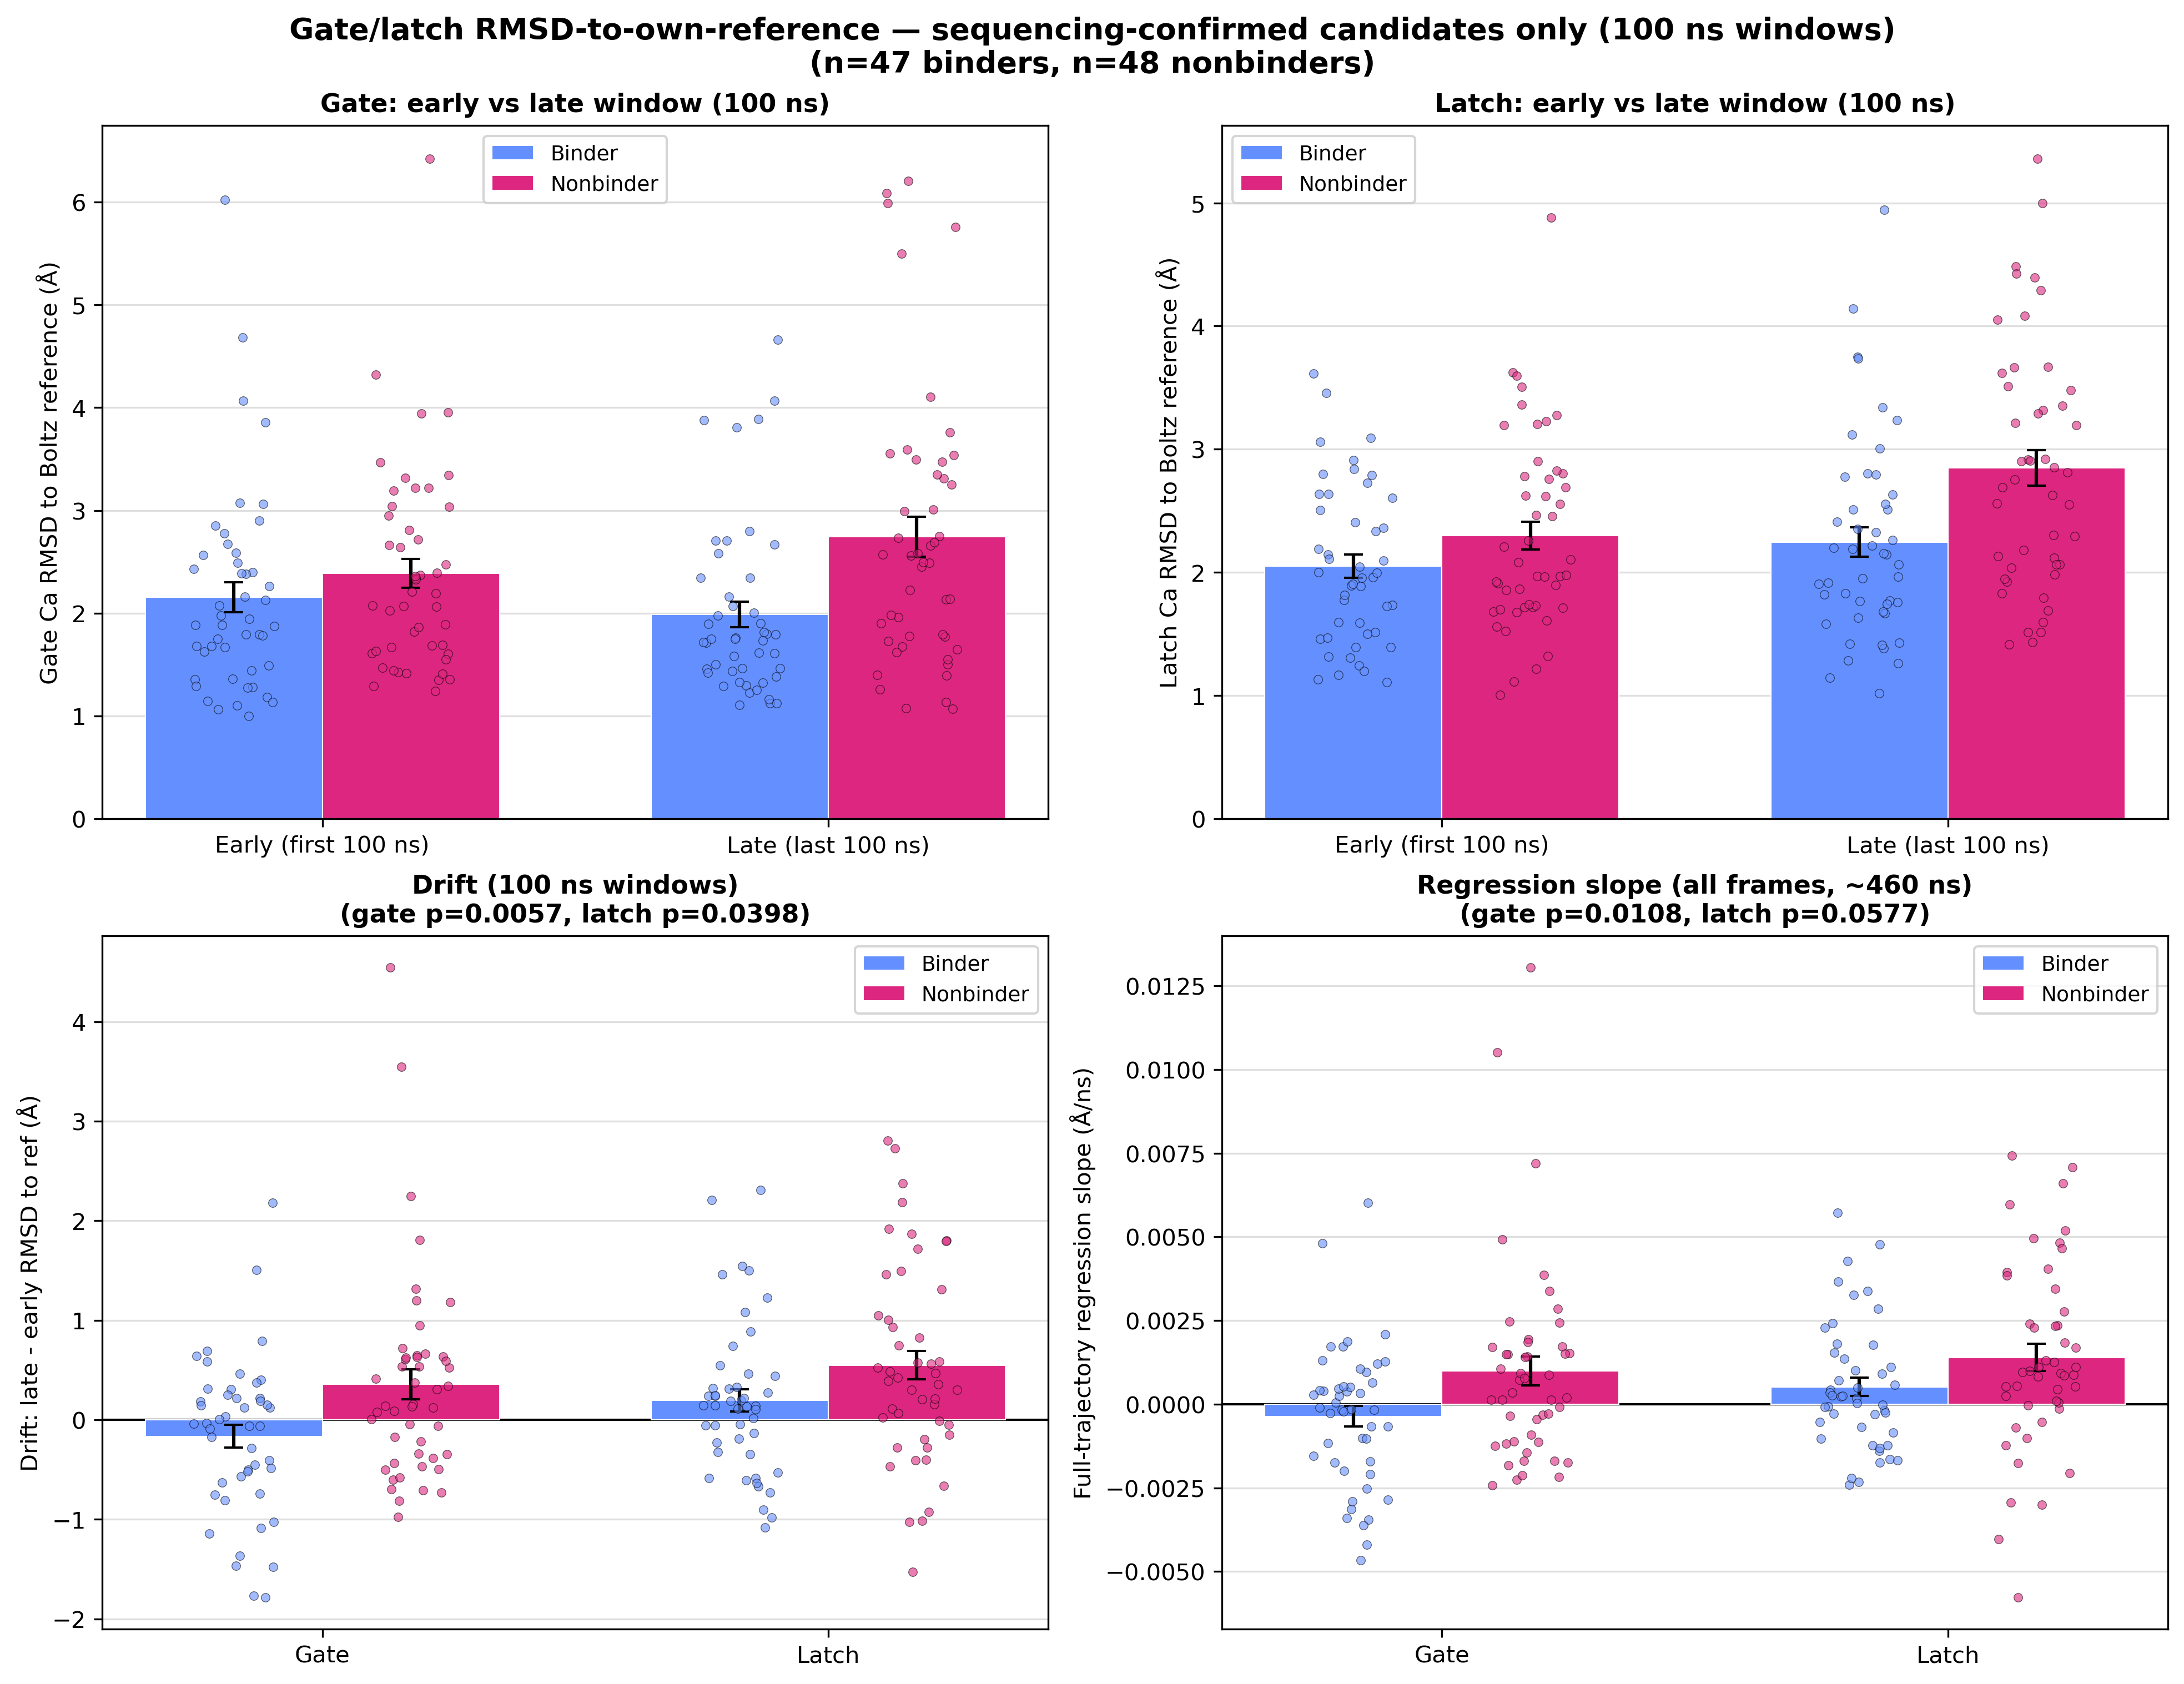

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), dpi=300, constrained_layout=True)
rng = np.random.default_rng(0)
axes_flat = axes.flatten()

# --- Panels 1-2: early vs late window (100 ns), absolute RMSD-to-ref ---
for ax, region in zip(axes_flat[:2], ["Gate", "Latch"]):
    x = np.arange(2)
    width = 0.35
    for gi, (group_disp, gdf, color) in enumerate([
        ("Binder", binder, GROUP_COLOR["Binder"]),
        ("Nonbinder", nb, GROUP_COLOR["False Positive"]),
    ]):
        cols = [f"{region} RMSD early100 mean (A)", f"{region} RMSD late100 mean (A)"]
        means = [gdf[c].mean() for c in cols]
        sems  = [gdf[c].sem() for c in cols]
        offset = -width / 2 if gi == 0 else width / 2
        ax.bar(x + offset, means, width, yerr=sems, capsize=4, color=color,
               edgecolor="white", linewidth=0.5, label=group_disp, zorder=2)
        for xi, c in zip(x, cols):
            jitter = rng.uniform(-0.08, 0.08, size=len(gdf))
            ax.scatter(xi + offset + jitter, gdf[c], color=color, edgecolor="black",
                       linewidth=0.3, s=14, alpha=0.6, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(["Early (first 100 ns)", "Late (last 100 ns)"])
    ax.set_ylabel(f"{region} Ca RMSD to Boltz reference (\u00c5)")
    ax.set_title(f"{region}: early vs late window (100 ns)", fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9)

# --- Panel 3: drift (100 ns windows) ---
ax = axes_flat[2]
x = np.arange(2)
width = 0.35
drift_cols = {"Gate": "Gate drift100 (A)", "Latch": "Latch drift100 (A)"}
for gi, (group_disp, gdf, color) in enumerate([
    ("Binder", binder, GROUP_COLOR["Binder"]),
    ("Nonbinder", nb, GROUP_COLOR["False Positive"]),
]):
    means = [gdf[drift_cols[r]].mean() for r in ["Gate", "Latch"]]
    sems  = [gdf[drift_cols[r]].sem() for r in ["Gate", "Latch"]]
    offset = -width / 2 if gi == 0 else width / 2
    ax.bar(x + offset, means, width, yerr=sems, capsize=4, color=color,
           edgecolor="white", linewidth=0.5, label=group_disp, zorder=2)
    for xi, r in zip(x, ["Gate", "Latch"]):
        jitter = rng.uniform(-0.08, 0.08, size=len(gdf))
        ax.scatter(xi + offset + jitter, gdf[drift_cols[r]], color=color, edgecolor="black",
                   linewidth=0.3, s=14, alpha=0.6, zorder=3)
ax.axhline(0, color="black", lw=1.0, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(["Gate", "Latch"])
ax.set_ylabel("Drift: late - early RMSD to ref (\u00c5)")
ax.set_title("Drift (100 ns windows)\n(gate p=0.0057, latch p=0.0398)", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=9)

# --- Panel 4: full-trajectory regression slope ---
ax = axes_flat[3]
x = np.arange(2)
width = 0.35
slope_cols = {"Gate": "Gate slope (A/ns)", "Latch": "Latch slope (A/ns)"}
for gi, (group_disp, gdf, color) in enumerate([
    ("Binder", binder, GROUP_COLOR["Binder"]),
    ("Nonbinder", nb, GROUP_COLOR["False Positive"]),
]):
    means = [gdf[slope_cols[r]].mean() for r in ["Gate", "Latch"]]
    sems  = [gdf[slope_cols[r]].sem() for r in ["Gate", "Latch"]]
    offset = -width / 2 if gi == 0 else width / 2
    ax.bar(x + offset, means, width, yerr=sems, capsize=4, color=color,
           edgecolor="white", linewidth=0.5, label=group_disp, zorder=2)
    for xi, r in zip(x, ["Gate", "Latch"]):
        jitter = rng.uniform(-0.08, 0.08, size=len(gdf))
        ax.scatter(xi + offset + jitter, gdf[slope_cols[r]], color=color, edgecolor="black",
                   linewidth=0.3, s=14, alpha=0.6, zorder=3)
ax.axhline(0, color="black", lw=1.0, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(["Gate", "Latch"])
ax.set_ylabel("Full-trajectory regression slope (\u00c5/ns)")
ax.set_title("Regression slope (all frames, ~460 ns)\n(gate p=0.0108, latch p=0.0577)", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=9)

fig.suptitle("Gate/latch RMSD-to-own-reference \u2014 sequencing-confirmed candidates only (100 ns windows)\n"
             f"(n={len(binder)} binders, n={len(nb)} nonbinders)", fontsize=13, fontweight="bold")
fig1_path = os.path.join(OUT_DIR, "gate_latch_rmsd_to_ref_early_late_ngs_observed.png")
fig.savefig(fig1_path, dpi=300, bbox_inches="tight")
print(f"Saved -> {fig1_path}")
plt.show()

## Figure 2: mean +/- IQR band over time, one panel per region

(Raw per-frame overlays for 47 sequences x ~12k frames are an unreadable noise
cloud; aggregate to a population mean + spread band instead.)

Saved -> /Users/ivanatang/Developer/biosensors/analysis/gate_latch/gate_latch_rmsd_to_ref_timeseries_ngs_observed.png


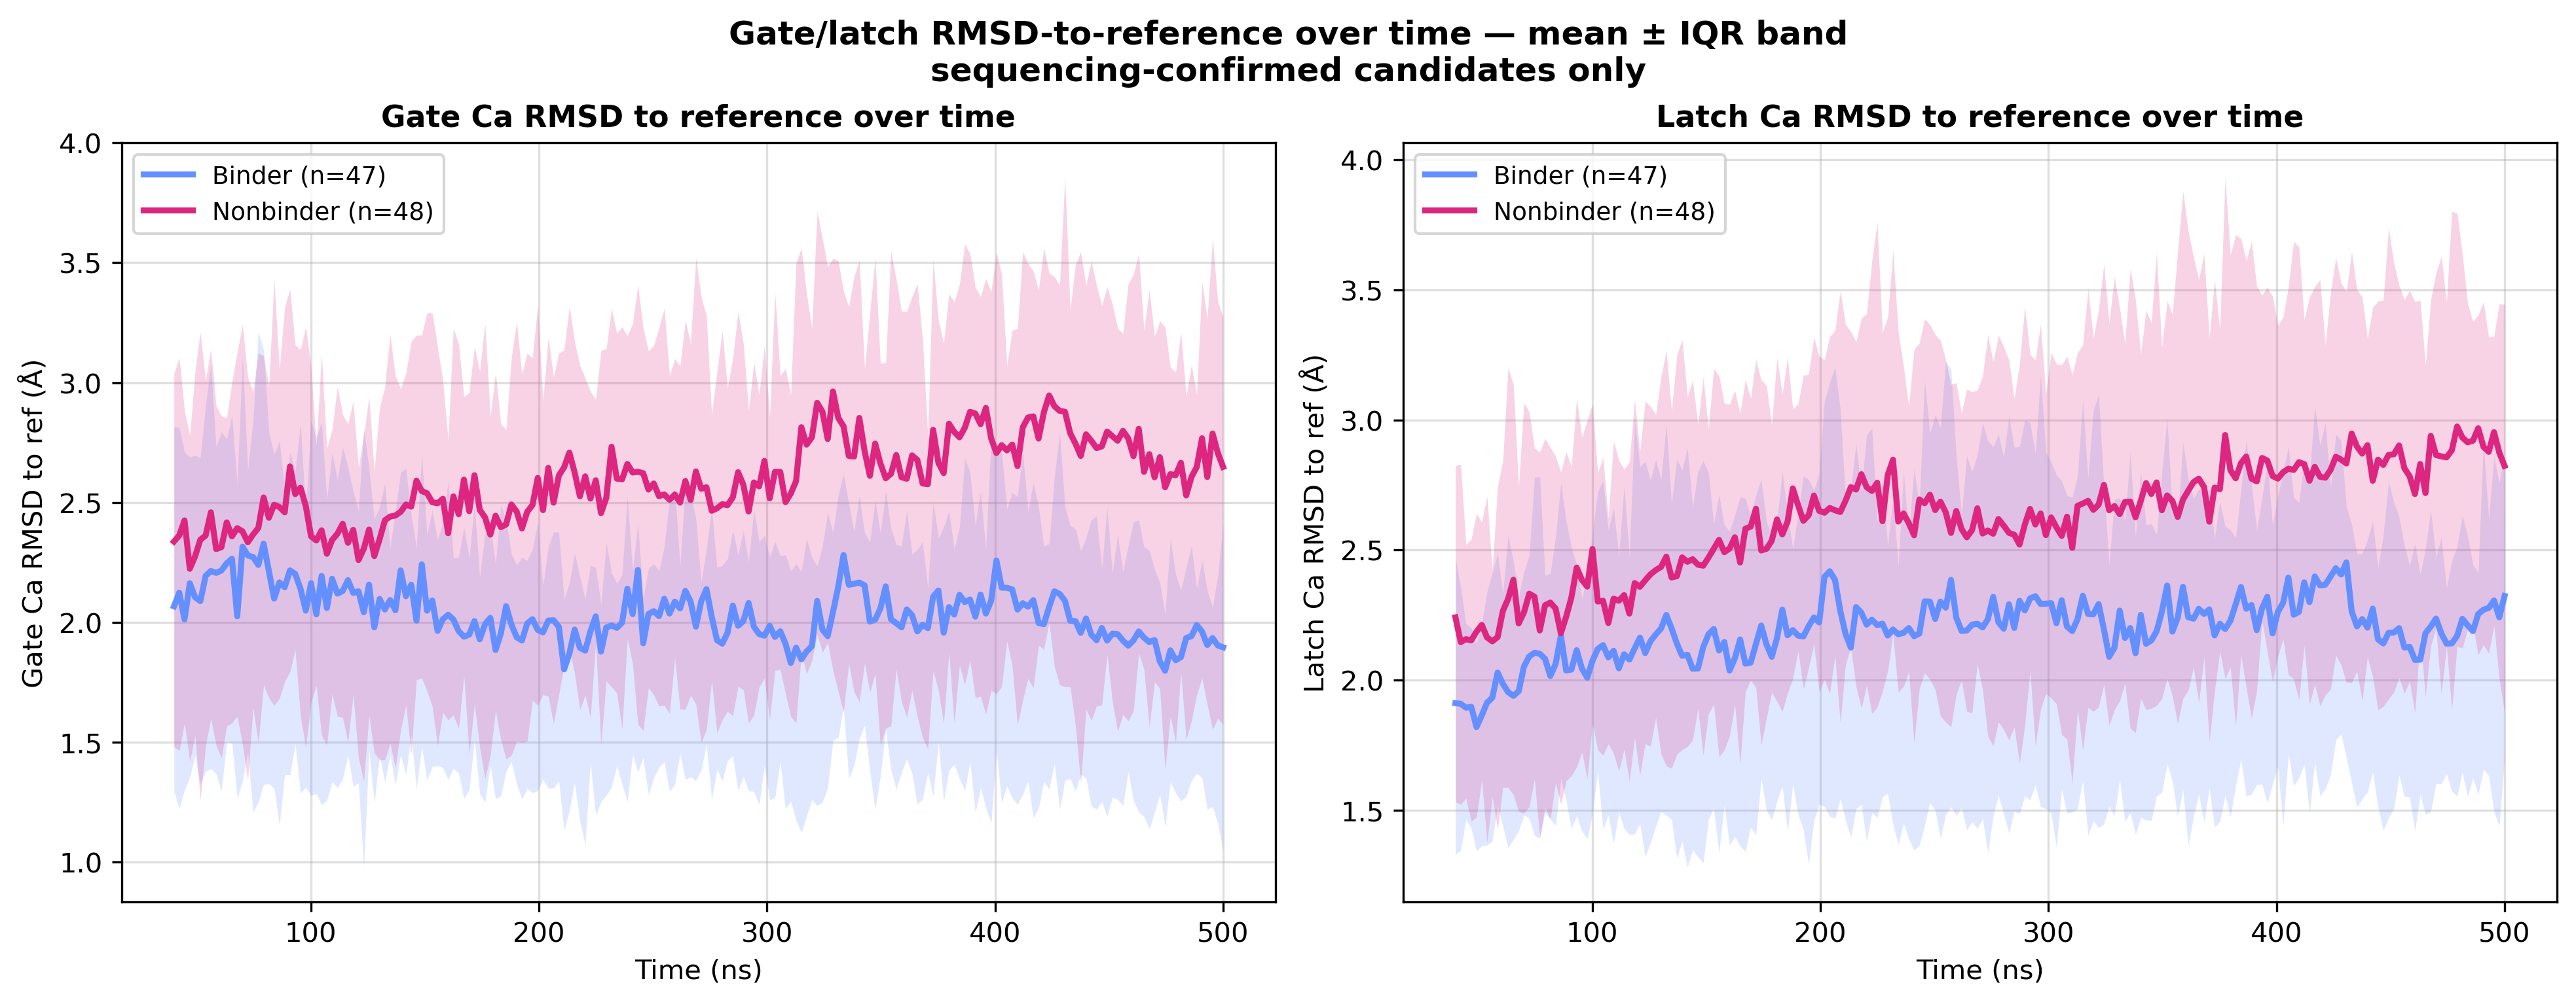

In [7]:
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5), dpi=300, constrained_layout=True)
region_files = {"Gate": "gate_rmsd_to_ref.xvg", "Latch": "latch_rmsd_to_ref.xvg"}
groups_plot = [("Binder", binder, GROUP_COLOR["Binder"]),
               ("Nonbinder", nb, GROUP_COLOR["False Positive"])]

for ax, region in zip(axes2, ["Gate", "Latch"]):
    for group_disp, gdf, color in groups_plot:
        all_t, all_v = [], []
        for _, row in gdf.iterrows():
            data = load_region_ts(row["Sequence"], row["Group"], region_files[region])
            if data is None:
                continue
            t, v = data
            all_t.append(t)
            all_v.append(v)
        if not all_t:
            continue
        tmin = max(t[0] for t in all_t)
        tmax = min(t[-1] for t in all_t)
        grid = np.linspace(tmin, tmax, 200)
        interp_vals = np.array([np.interp(grid, t, v) for t, v in zip(all_t, all_v)])
        mean_trend = interp_vals.mean(axis=0)
        p25 = np.percentile(interp_vals, 25, axis=0)
        p75 = np.percentile(interp_vals, 75, axis=0)
        ax.fill_between(grid, p25, p75, color=color, alpha=0.2, linewidth=0)
        ax.plot(grid, mean_trend, color=color, lw=2.2,
                label=f"{group_disp} (n={len(all_t)})")
    ax.set_title(f"{region} Ca RMSD to reference over time", fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel(f"{region} Ca RMSD to ref (\u00c5)")
    ax.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9)
fig2.suptitle("Gate/latch RMSD-to-reference over time \u2014 mean \u00b1 IQR band\n"
              "sequencing-confirmed candidates only", fontsize=12, fontweight="bold")
fig2_path = os.path.join(OUT_DIR, "gate_latch_rmsd_to_ref_timeseries_ngs_observed.png")
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"Saved -> {fig2_path}")
plt.show()